# 0. Load Data

## 0.1 Load Data

In [ ]:
"""Load Data
Structure:
    1. Imports, Variables, Functions
    2. Load Data
"""

# 1. Imports, Variables, Functions
# imports
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io 
logging.basicConfig(level=logging.INFO)

# variables
run_dir = os.path.join("..","..","outputs","run-25-09-16-02") 
output_dir = os.path.join(run_dir, "outputs")
com_tsv_path = "/aloy/home/ddalton/databases/HuDiNe/AllNet5.tsv"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# functions

# 2. Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-09-12-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: rand_stratified
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT_BATCH_LABELS: False
do_combat: False
ontology: do
scgpt_pp: norm_log1p
description: 
library: RNA-Seq
use_controls: True
use_control_loss: False


In [2]:
split_idx = 0

# load all adata
adata_test =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)  
adata_valid =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)  
adata_train =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)  

## 0.2 Load Comorbidity Pairs

In [ ]:
import ast
# load do graph
do_graph = ut.load_do_graph()

# map doid to term
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}

# map doid to icd
doid_to_icd = dict()
for node, data in do_graph.nodes(data=True):
    for ref in data.get("xref", []):
        if ref.startswith("ICD9CM:"):
            icd = ref.split(":")[1]
            doid_to_icd[node] = icd

# map icd to doid
icd_to_doid = {v: k for k, v in doid_to_icd.items()}

# load comorbidity pairs
df_com = pd.read_csv(com_tsv_path, sep="\t", dtype=str).rename(columns=lambda c: c.strip())
print(f"Loaded {df_com.shape[0]} comorbidity pairs")

# map comorbidity ICD pairs to DOID
df_com["doid_1"] = df_com["#icd9-1"].map(icd_to_doid)
df_com["doid_2"] = df_com["icd9-2"].map(icd_to_doid)
df_com["name_1"] = df_com["doid_1"].map(doid_to_term)
df_com["name_2"] = df_com["doid_2"].map(doid_to_term)

# drop all rows with NA doid
df_com.dropna(subset=["doid_1", "doid_2"], how="any", inplace=True)
print(f"Mapped to {df_com.shape[0]} comorbidity pairs with DOID")

# filter down to those present in our data
_all_doids = list(adata_train.obs["doid_id"].unique())
df_com = df_com.query("doid_1 in @_all_doids and doid_2 in @_all_doids")
print(f"Filtered to {df_com.shape[0]} comorbidity pairs with DOID present in data")

# create sorted pair column
df_com["pair_sorted"] = df_com.apply(lambda row: str(tuple(sorted([row["doid_1"], row["doid_2"]]))), axis=1)

# fix column formats
df_com["n.common"] = df_com["n.common"].astype(int)
df_com["RR"] = df_com["RR"].astype(float)
df_com["pair_sorted"] = df_com["pair_sorted"].apply(ast.literal_eval)


Loaded 6088553 comorbidity pairs
Mapped to 225744 comorbidity pairs with DOID
Filtered to 446 comorbidity pairs with DOID present in data


In [16]:
df_com

,#icd9-1,icd9-2,n1,n2,n.common,RR,RR.low,RR.high,pval,pval.adj,doid_1,doid_2,name_1,name_2,pair_sorted
141542,030,428.0,2,2343516,1,2.781935,0.20662424488693,37.4552459363983,0.00032667643131433,0.500093951541559,DOID:1024,DOID:6000,leprosy,congestive heart failure,"(DOID:1024, DOID:6000)"
141556,030,564.1,2,68078,1,95.765284,7.11276381321136,1289.37074936821,0.00268880635527155,0.701549162774235,DOID:1024,DOID:9778,leprosy,irritable bowel syndrome,"(DOID:1024, DOID:9778)"
624179,135,154.1,6908,43013,11,0.482709,0.220409106339276,1.05716184546206,-0.00068517032797409,-0.142098148439253,DOID:11335,DOID:1993,sarcoidosis,rectum cancer,"(DOID:11335, DOID:1993)"
624238,135,183.0,6908,27393,12,0.826864,0.39036641594227,1.75144281350818,-0.000182898283583849,-0.0302700808586769,DOID:11335,DOID:2394,sarcoidosis,ovarian cancer,"(DOID:11335, DOID:2394)"
624347,135,203.0,6908,7923,9,2.144102,0.9012745077071,5.10074639866493,0.000649513006733088,0.0578066697926136,DOID:11335,DOID:9538,sarcoidosis,multiple myeloma,"(DOID:11335, DOID:9538)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399362,710.2,714.0,6892,175906,1489,16.014510,14.9711292511428,17.1306073850891,0.040377875992967,16.9486709219018,DOID:12894,DOID:7148,Sjogren's syndrome,rheumatoid arthritis,"(DOID:12894, DOID:7148)"
5399494,710.2,720.0,6892,6375,32,9.496628,5.99735352551419,15.0376218924225,0.00432150903489894,0.358714631731391,DOID:12894,DOID:7147,Sjogren's syndrome,ankylosing spondylitis,"(DOID:12894, DOID:7147)"
5423569,714.0,720.0,175906,6375,1506,17.510922,16.3762914745442,18.7241654278765,0.0427034018104937,17.9265483791382,DOID:7148,DOID:7147,rheumatoid arthritis,ankylosing spondylitis,"(DOID:7147, DOID:7148)"
5424127,714.0,758.7,175906,149,4,1.989931,0.54231954720795,7.30164393965983,0.000391331918484729,0.164128183490042,DOID:7148,DOID:1921,rheumatoid arthritis,Klinefelter syndrome,"(DOID:1921, DOID:7148)"


In [ ]:
_df_com_100 = df_com[df_com["n.common"]>100]
print(f"Filtered to {df_com.shape[0]} comorbidity pairs with >100 common patients")


for rr_i in [1, 2, 5, 10]:
    _df_q = _df_com_100[(_df_com_100["RR"]>rr_i)& (_df_com_100["pval.adj"]<0.05)]
    print(f"Filtered to {_df_q.shape[0]} comorbidity pairs with RR>{rr_i}")


Filtered to 446 comorbidity pairs with >100 common patients
Filtered to 64 comorbidity pairs with RR>1
Filtered to 22 comorbidity pairs with RR>2
Filtered to 8 comorbidity pairs with RR>5
Filtered to 6 comorbidity pairs with RR>10


In [20]:
_df_com_100["pval.adj"] = _df_com_100["pval.adj"].astype(float)

/tmp/ipykernel_11659/3805197840.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df_com_100["pval.adj"] = _df_com_100["pval.adj"].astype(float)


In [ ]:
# _df_com_100 = df_com[df_com["n.common"]>100]
print(f"Filtered to {df_com.shape[0]} comorbidity pairs with >100 common patients")


for rr_i in [1, 2, 5, 10]:
    _df_q = _df_com_100[(_df_com_100["RR"]>rr_i)& (_df_com_100["pval.adj"]<2)]
    print(f"Filtered to {_df_q.shape[0]} comorbidity pairs with RR>{rr_i}")


Filtered to 446 comorbidity pairs with >100 common patients
Filtered to 64 comorbidity pairs with RR>1
Filtered to 22 comorbidity pairs with RR>2
Filtered to 8 comorbidity pairs with RR>5
Filtered to 6 comorbidity pairs with RR>10


In [27]:
_df_com_100[(_df_com_100["RR"]>1)]

,#icd9-1,icd9-2,n1,n2,n.common,RR,RR.low,RR.high,pval,pval.adj,doid_1,doid_2,name_1,name_2,pair_sorted
625298,135,428.0,6908,2343516,1598,1.287068,1.20602987919301,1.37355087049508,0.00309375967585099,4.736117,DOID:11335,DOID:6000,sarcoidosis,congestive heart failure,"(DOID:11335, DOID:6000)"
625615,135,530.1,6908,425051,281,1.247837,1.06855998430711,1.45719194072175,0.00104744080336909,0.682888,DOID:11335,DOID:11963,sarcoidosis,esophagitis,"(DOID:11335, DOID:11963)"
626108,135,714.0,6908,175906,113,1.212524,0.949441678890986,1.54850424434395,0.000572195047091499,0.239984,DOID:11335,DOID:7148,sarcoidosis,rheumatoid arthritis,"(DOID:11335, DOID:7148)"
1241142,203.0,428.0,7923,2343516,2225,1.562490,1.47871044688966,1.65101683429132,0.00649236250604639,9.939069,DOID:9538,DOID:6000,multiple myeloma,congestive heart failure,"(DOID:6000, DOID:9538)"
1241462,203.0,530.1,7923,425051,300,1.161543,0.999642079031242,1.34966614350997,0.000731203509492823,0.476714,DOID:9538,DOID:11963,multiple myeloma,esophagitis,"(DOID:11963, DOID:9538)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5396848,710.0,714.0,21900,175906,1552,5.253054,4.91759648253813,5.61139419034205,0.0204001234539712,8.557778,DOID:9074,DOID:7148,systemic lupus erythematosus,rheumatoid arthritis,"(DOID:7148, DOID:9074)"
5398321,710.1,710.2,7661,6892,215,53.094876,44.4677615634985,63.3957229813574,0.0290474438305915,2.543181,DOID:418,DOID:12894,systemic scleroderma,Sjogren's syndrome,"(DOID:12894, DOID:418)"
5398353,710.1,714.0,7661,175906,349,3.376791,2.93807552039684,3.88101604314279,0.00673916711672044,2.826532,DOID:418,DOID:7148,systemic scleroderma,rheumatoid arthritis,"(DOID:418, DOID:7148)"
5399362,710.2,714.0,6892,175906,1489,16.014510,14.9711292511428,17.1306073850891,0.040377875992967,16.948671,DOID:12894,DOID:7148,Sjogren's syndrome,rheumatoid arthritis,"(DOID:12894, DOID:7148)"


## 0.3 Load Disease Ontology Pairs

In [7]:
"""0.3 Load Disease Ontology Pairs
Load pairs of related and unrelated diseases from the Disease Ontology.
Structure:
    1. Imports, Variables, Functions
    2. Load Disease Pairs

"""
# 1. Imports, Variables, Functions
# imports


# variables

# functions


# 2. Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = ut.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = ut.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}


# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}")


# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}")
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}")
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)


df_train = adata_train.obs.copy()
df_test = adata_test.obs.copy()
df_valid = adata_valid.obs.copy()

df_all = pd.concat([df_train, df_valid, df_test], axis=0)
df_all = df_all.query("doid_id != 'Control'")

dsaid_2_dis = dict(zip(df_all["dsaid"], df_all["doid_id"]))


Loaded universe of disease pairs: 70442515
IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (7503, 8)
Nº of significant pairs in dataset (top 5% IC): (917, 8)
Nº of significant pairs in dataset (top 1% IC): (354, 8)
Nº of negative pairs in dataset (outside 5%): (6586, 8)


# 1. Compute Similarity


In [8]:
"""Here we will evaluate the Embeddings
Analyze how well the embeddings capture same disease as well as related diseases
"""

# 1. Imports, Variables, Functions
# imports
from typing import *
from scipy.spatial.distance import cdist
import itertools
import obonet
import networkx as nx
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
import logging
import os
# variable


# functions

# 2. Load Data

# load scGPT embeddings
embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])

# compute cosine similarity between all embeddings
c_matrix_train = 1 - cdist(embeddings_train, embeddings_train, "cosine")
c_matrix_valid = 1 - cdist(embeddings_valid, embeddings_valid, "cosine")
c_matrix_test = 1 - cdist(embeddings_test, embeddings_test, "cosine")

# compute cosine similarity between sets
c_matrix_test_vs_train = 1 - cdist(embeddings_test, embeddings_train, "cosine")
c_matrix_valid_vs_train = 1 - cdist(embeddings_valid, embeddings_train, "cosine")



# 2. Benchmark Comorbidities

In [9]:

# imports 
from matplotlib.ticker import EngFormatter
import random

# variables

# functions

def get_com_sim(
    adata_qry, adata_ref, RR_thrs, c_matrix, df_com,  sample:int=10000000
):
    fmt = EngFormatter(places=1)
   
   # select datasets & do_ids
    do_ids_qry = adata_qry.obs["do_id"].values
    datasets_qry = adata_qry.obs["dataset"].values

    do_ids_ref = adata_ref.obs["do_id"].values
    datasets_ref = adata_ref.obs["dataset"].values

    c_all = list()
    w_all = list()
    l_all = list()
    _sample_sizes = list()
    
    # get related pairs
    for thr in RR_thrs:
        _df_com = df_com.query("RR>@thr")
        print(f"Filtering to {len(_df_com)} comorbidity pairs with RR>{thr}")
        if len(_df_com)==0:
            continue
        related_idxs, _l_related = vz.get_doid_idxs_pairs_split(list(_df_com["pair_sorted"]), do_ids_qry, do_ids_ref, datasets_qry, datasets_ref, return_weights=True)
        print(f"Nº of comorbidity disease pairs : {len(related_idxs)}")

        # convert label to weights - all pairs add to 1
        _w_related = vz._convert_labels_to_weights(_l_related)

        if sample & (len(related_idxs) > sample):
            _sample_i = random.sample(range(len(related_idxs)), sample)
            related_idxs = related_idxs[_sample_i]
            _w_related = _w_related[_sample_i]

        # retrieve similarities
        _c_related = c_matrix[related_idxs[:, 0], related_idxs[:, 1]]

        # append values
        c_all.append(_c_related)
        w_all.append(_w_related)
        _sample_sizes.append(len(_c_related))

        # append labels
        l_all.append(f"Comorbidities RR +{thr} | {len(_df_com)} pairs | {fmt(len(_c_related))} comps",)

    return c_all, w_all, l_all


# define related and unrelated dataframes
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)



# get similarity of unrelated diseases
ts_s_unr,_,_ =vz.get_unrelated_pairs_split_2(adata_test, adata_train, c_matrix_test_vs_train, df_unrelated, dsaid_2_dis,sample_size=10000, include_control=True)
vl_s_unr,_,_ = vz.get_unrelated_pairs_split_2(adata_valid, adata_train, c_matrix_valid_vs_train, df_unrelated, dsaid_2_dis,sample_size=10000, include_control=True)
tr_s_unr = vz.get_unrelated_pairs(
    adata_train.obs,
    do_df_ic_query,
    c_matrix_train,
    n_samples=10000,
    seed=42,
)



# get comorbidity similarities
c_com_train, w_com_train, l_com_train = get_com_sim(
    adata_train, adata_train, [1,1.5,2,5,10], c_matrix_train, _df_com_100, sample=10000000
)
c_com_valid, w_com_valid, l_com_valid = get_com_sim(
    adata_valid, adata_train, [1,1.5,2,5,10], c_matrix_valid_vs_train, _df_com_100, sample=10000000
)
c_com_test, w_com_test, l_com_test = get_com_sim(
    adata_test, adata_train, [1,1.5, 2, 5, 10], c_matrix_test_vs_train, _df_com_100, sample=10000000
)

100%|██████████| 6586/6586 [01:10<00:00, 94.05it/s] 


124 diseases in dataset


7626it [00:20, 372.63it/s]


139029317 unrelated pairs found
10000
Selected 10000 unrelated pairs
Sampled pairs: 10000
Filtering to 310 comorbidity pairs with RR>1


  0%|          | 0/310 [00:00<?, ?it/s]


ValueError: too many values to unpack (expected 2)

In [13]:
c_com_train, w_com_train, l_com_train = get_com_sim(
    adata_train, adata_train, [1,1.5,2,5,10], c_matrix_train, _df_com_100, sample=10000000
)
c_com_valid, w_com_valid, l_com_valid = get_com_sim(
    adata_valid, adata_train, [1,1.5,2,5,10], c_matrix_valid_vs_train, _df_com_100, sample=10000000
)
c_com_test, w_com_test, l_com_test = get_com_sim(
    adata_test, adata_train, [1,1.5, 2, 5, 10], c_matrix_test_vs_train, _df_com_100, sample=10000000
)

Filtering to 64 comorbidity pairs with RR>1


100%|██████████| 64/64 [00:01<00:00, 32.05it/s]


Nº of comorbidity disease pairs : 878800
Filtering to 32 comorbidity pairs with RR>1.5


100%|██████████| 32/32 [00:01<00:00, 28.02it/s]


Nº of comorbidity disease pairs : 509726
Filtering to 22 comorbidity pairs with RR>2


...

Nº of comorbidity disease pairs : 45582
Filtering to 8 comorbidity pairs with RR>5


100%|██████████| 8/8 [00:00<00:00, 148.44it/s]


Nº of comorbidity disease pairs : 19623
Filtering to 6 comorbidity pairs with RR>10


100%|██████████| 6/6 [00:00<00:00, 227.82it/s]

Nº of comorbidity disease pairs : 10190


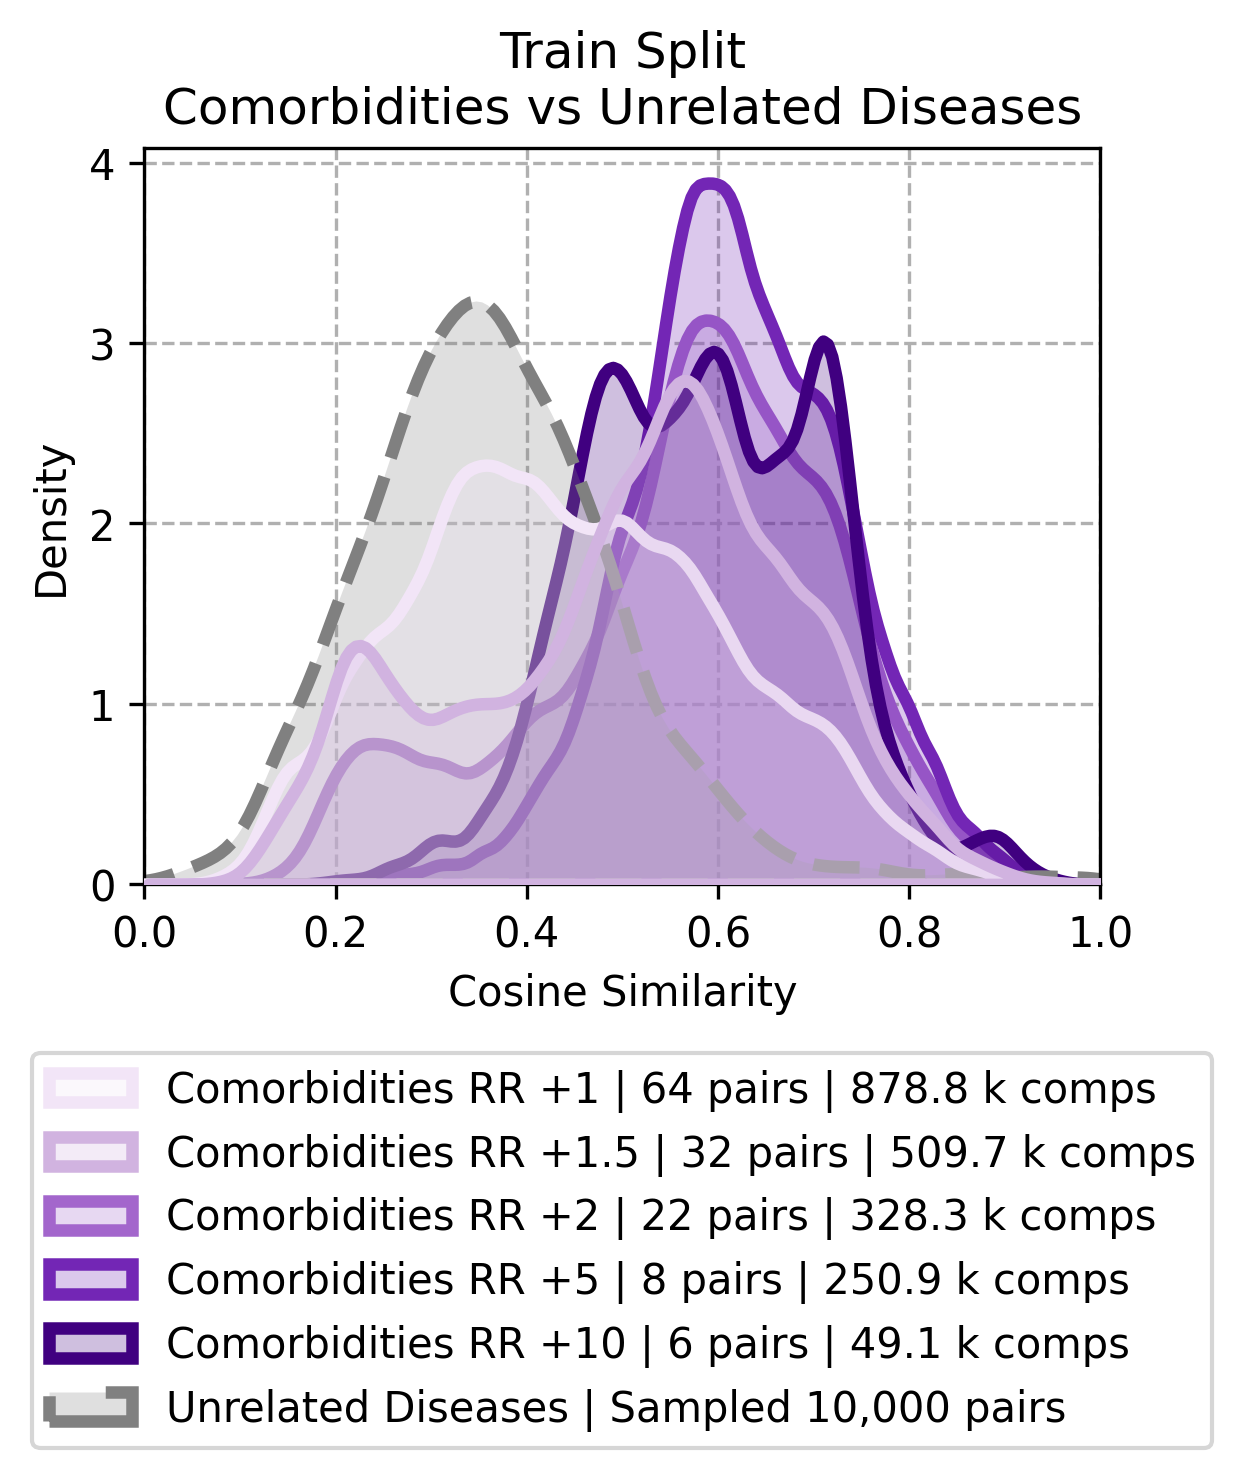

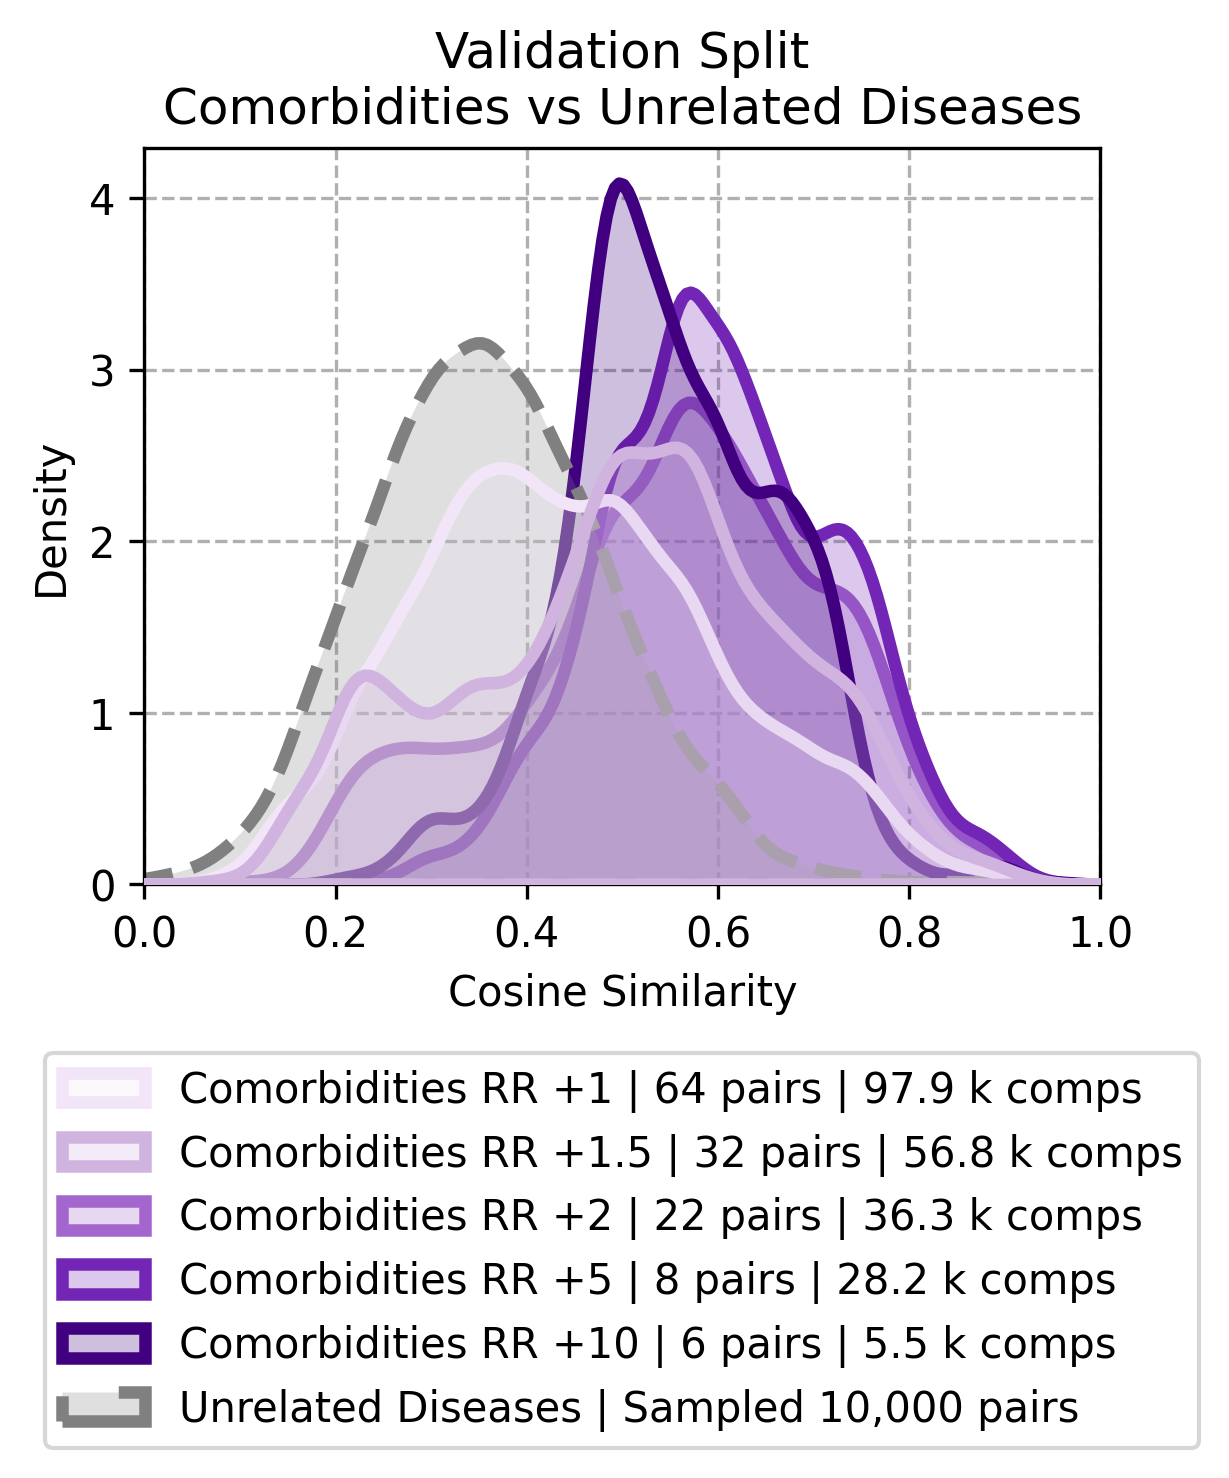

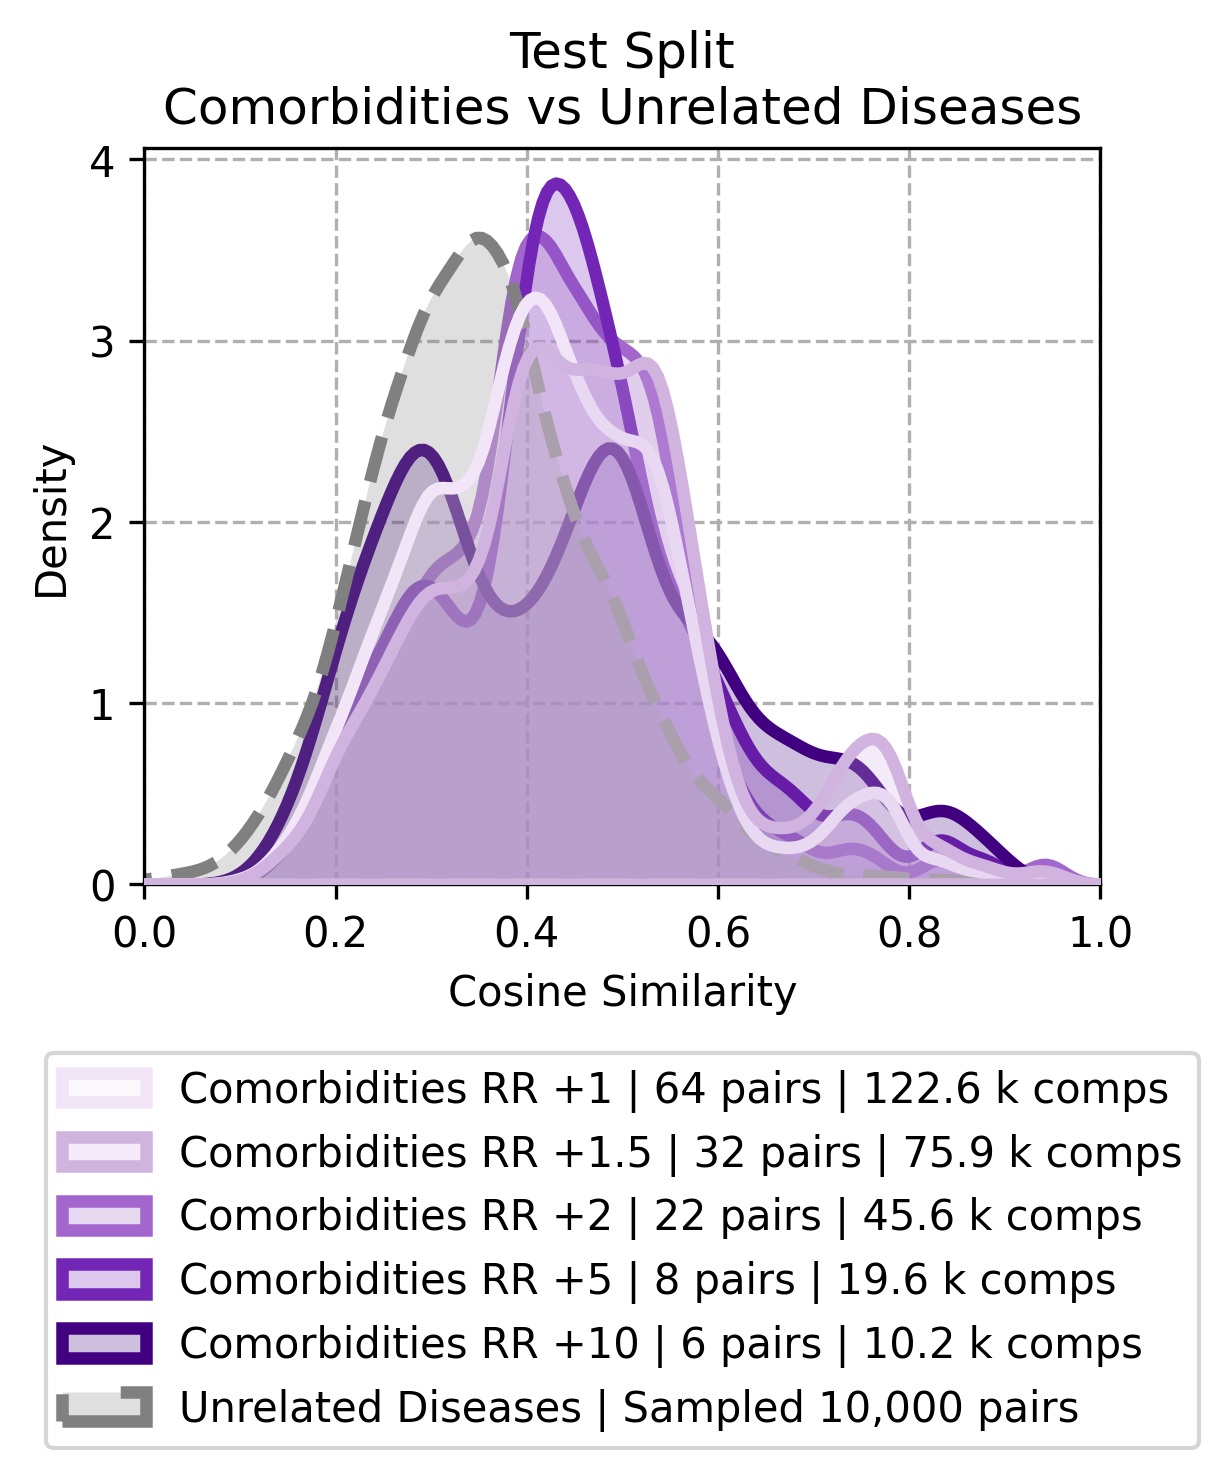

In [ ]:
purple_scale = ["#f2e5f7", "#d1b3e0", "#a366cc", "#7326b5", "#400080"]

vz.plot_kde(c_com_train + [tr_s_unr], 
            labels=l_com_train + ["Unrelated Diseases | Sampled 10,000 pairs"],
            title="Train Split\nComorbidities vs Unrelated Diseases",
            colors=purple_scale + ["grey"] ,
            weights = None,
            sample = 1000000,   
            metric="Cosine Similarity")

vz.plot_kde(c_com_valid + [vl_s_unr], 
            labels=l_com_valid + ["Unrelated Diseases | Sampled 10,000 pairs"],
            title="Validation Split\nComorbidities vs Unrelated Diseases",
            colors=purple_scale + ["grey"] ,
            weights = None,
            sample = 1000000,
            metric="Cosine Similarity")


vz.plot_kde(c_com_test + [ts_s_unr], 
            labels=l_com_test + ["Unrelated Diseases | Sampled 10,000 pairs"],
            title="Test Split\nComorbidities vs Unrelated Diseases",
            colors=purple_scale + ["grey"] ,
            sample= 1000000,
            weights = None,
            metric="Cosine Similarity")

In [ ]:
import random
import tqdm
from scanpy import AnnData as Anndata

def get_comorb_per_dis(adata_qry:Anndata, adata_ref:Anndata, df_related:pd.DataFrame, df_unrelated:pd.DataFrame, c_matrix:np.ndarray, doid_to_term:dict)->pd.DataFrame:
    results_per_dis = list()
    for doid_i in tqdm(adata_qry.obs["doid_id"].unique()):
        if doid_i == "Control":
            continue
        # get related & unrelated diseases
        related_i = set(df_related.query(f"do1 == '{doid_i}'")["do2"].values)
        related_i = related_i.union(set(df_related.query(f"do2 == '{doid_i}'")["do1"].values))
        related_i = list(related_i)

        unrelated_i = set(df_unrelated.query(f"do1 == '{doid_i}'")["do2"].values)
        unrelated_i = unrelated_i.union(set(df_unrelated.query(f"do2 == '{doid_i}'")["do1"].values))
        unrelated_i = list(unrelated_i)

        # get idxs
        idx_1 = np.array(adata_qry.obs.query(f"(doid_id == '{doid_i}')").index).astype(int)    # query disease
        idx_2 = np.array(adata_ref.obs.query(f"(doid_id == '{doid_i}')").index).astype(int)    # reference disease
        idx_3 = np.array(adata_ref.obs.query(f"(doid_id in @related_i)").index).astype(int)  # reference unrelated diseases
        idx_4 = np.array(adata_ref.obs.query(f"(doid_id in @unrelated_i)").index).astype(int)  # reference unrelated diseases
        dsaids = adata_ref.obs.query(f"(doid_id in @unrelated_i)")["dsaid"].unique()
        idx_5 = np.array(adata_ref.obs.query(f"(dsaid in @dsaids)").index).astype(int)  # reference unrelated diseases

        if len(idx_1) == 0 or len(idx_2) == 0 or len(idx_5) == 0:
            print(f"Skipping {doid_i} - {doid_to_term.get(doid_i)} due to lack of pairs")
            print(f"Nº same: {len(idx_2)}\tNº unrelated: {len(idx_5)}")
            continue
        
        idx_pairs_1 = np.array(list(itertools.product(idx_1, idx_2)))
        idx_pairs_2 = np.array(list(itertools.product(idx_1, idx_5)))

        _s_same = c_matrix[idx_pairs_1[:, 0], idx_pairs_1[:, 1]]
        _s_unrelated = c_matrix[idx_pairs_2[:, 0], idx_pairs_2[:, 1]]        

        # results per disease
        ap_i = average_precision_score(
            [1] * len(_s_same) + [0] * (len(_s_unrelated)),
            np.concatenate([_s_same, _s_unrelated])
        )
        random_i = len(_s_same) / (len(_s_same) + len(_s_unrelated)) if (len(_s_same) + len(_s_unrelated)) > 0 else 0
        auroc_i = roc_auc_score(
            [1] * len(_s_same) + [0] * (len(_s_same)),
            np.concatenate([_s_same, np.array(random.sample(list(_s_unrelated), len(_s_same)))])
        )
        
        results_per_dis.append({
            "average_precision": ap_i,
            "roc_auc": auroc_i,
            "random": random_i,
            "disease": doid_to_term.get(doid_i),
            "doid": doid_i,
            "n_positives": len(_s_same),
            "n_unrelated": len(_s_unrelated),
        })

        df_per_dis = pd.DataFrame(results_per_dis)

    return df_per_dis

In [ ]:
import pandas as pd

def _auroc(pos, neg):
    """Return only the AUROC from vz.get_roc(pos, neg)."""
    # both most be same size!
    min_size = min(len(pos), len(neg))
    pos = np.array(pos)
    neg = np.array(neg)

    auroc, _, _ = vz.get_roc(pos, neg)
    return auroc

def comb_make_auroc_row(split_name:str, c_com:np.array, s_unr:np.array, ndigits:int=3):
    return pd.DataFrame({
        "Split": [split_name],
        "Comorbidity +1 RR": [round(_auroc(c_com[0], s_unr),ndigits=ndigits)],
        "Comorbidity +1.5 RR": [round(_auroc(c_com[1], s_unr),ndigits=ndigits)],
        "Comorbidity +2 RR": [round(_auroc(c_com[2], s_unr),ndigits=ndigits)],
        "Comorbidity +5 RR": [round(_auroc(c_com[3], s_unr),ndigits=ndigits)],
        "Comorbidity +10 RR": [round(_auroc(c_com[4], s_unr),ndigits=ndigits)],
    })


#! IMPORTANT - HERE THE RANDOMS ARE BUILT USING UNRELATED DISEASES & THEIR CONTROLS
# Build each split row
df_auroc_train = comb_make_auroc_row(
    "Train",
    c_com_train,
    tr_s_unr
)

df_auroc_valid = comb_make_auroc_row(
    "Valid",
    c_com_valid,
    vl_s_unr
)

df_auroc_test = comb_make_auroc_row(
    "Test",
    c_com_test,
    ts_s_unr
)

# Optional: one tidy table
df_auroc = pd.concat([df_auroc_train, df_auroc_valid, df_auroc_test], ignore_index=True)

# save 
# df_auroc.to_csv(os.path.join(output_dir, "gex_auroc_random_all.csv"), index=False)
# df_auroc

Nº of positive disease pairs: 878800
Nº of positive disease pairs: 509726
Nº of positive disease pairs: 328310
Nº of positive disease pairs: 250880
Nº of positive disease pairs: 49108
Nº of positive disease pairs: 97852
Nº of positive disease pairs: 56752
Nº of positive disease pairs: 36288
Nº of positive disease pairs: 28190
Nº of positive disease pairs: 5481
Nº of positive disease pairs: 122607
Nº of positive disease pairs: 75928
Nº of positive disease pairs: 45582
Nº of positive disease pairs: 19623
Nº of positive disease pairs: 10190


In [3]:
df_auroc

NameError: name 'df_auroc' is not defined